In [1]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 5.9 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time
import optuna
from optuna.samplers import TPESampler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)
from google.colab import files

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

In [3]:
FEATURE_COLS = [
    'Electrical speed [rad/s]',
    'I_M_a', 'I_M_b', 'I_M_c',
    'I_P_a', 'I_P_b', 'I_P_c',
    'I_B_a', 'I_B_b', 'I_B_c',
    'V_M_a', 'V_M_b', 'V_M_c',
    'V_P_a', 'V_P_b', 'V_P_c',
    'V_B_a', 'V_B_b', 'V_B_c'
]
LABEL_COL = 'Class label'

def optimize_svm(X, y, n_trials=50, name=""):
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    def objective(trial):
        C = trial.suggest_float('C', 1e-1, 1e4, log=True)
        gamma = trial.suggest_float('gamma', 1e-4, 1e1, log=True)
        svc = SVC(C=C, gamma=gamma, kernel='rbf', class_weight='balanced')
        return cross_val_score(svc, X, y, cv=cv, scoring='accuracy', n_jobs=-1).mean()
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    C_opt = study.best_params['C']
    gamma_opt = study.best_params['gamma']
    print(f"  [{name}] Best: C={C_opt:.4f}, gamma={gamma_opt:.6f}, CV={study.best_value:.4f}")
    return C_opt, gamma_opt

# 1. Chargement des données

In [15]:
#add as much file as you wish
uploaded = files.upload()

dfs = []
for fname in sorted(uploaded.keys()):
    df_tmp = pd.read_csv(fname)
    dfs.append(df_tmp)
    print(f"  {fname}: {len(df_tmp)} samples")

df1 = pd.concat(dfs, ignore_index=True)
X_all = df1[FEATURE_COLS].values
y_all = df1[LABEL_COL].values

print(f"\nTotal: {len(y_all)} samples")
for c in sorted(np.unique(y_all)):
    print(f"  Class {c:2d} : {np.sum(y_all == c):4d} samples")

Saving data_exp8.csv to data_exp8 (1).csv
Saving data_exp9.csv to data_exp9.csv
  data_exp8 (1).csv: 6796 samples
  data_exp9.csv: 5305 samples

Total: 12101 samples
  Class  1 :   82 samples
  Class  2 :  806 samples
  Class  3 :  810 samples
  Class  4 :  815 samples
  Class  5 :  810 samples
  Class  6 :  810 samples
  Class  7 :  810 samples
  Class  8 :  810 samples
  Class  9 :  810 samples
  Class 10 :  810 samples
  Class 11 :  810 samples
  Class 12 :  810 samples
  Class 13 :  810 samples
  Class 14 :  810 samples
  Class 15 :  768 samples
  Class 16 :  720 samples


In [16]:
KNOWN_CLASSES = [1, 2, 3, 4, 5, 6, 7, 8]
NEW_CLASSES   = [9, 10, 11, 12, 13, 14, 15, 16]

mask_known = np.isin(y_all, KNOWN_CLASSES)
X_known = X_all[mask_known]
y_known = y_all[mask_known]

X_known_train, X_known_test, y_known_train, y_known_test = train_test_split(
    X_known, y_known, test_size=0.2, stratify=y_known, random_state=42
)

new_class_data = {}
for c in NEW_CLASSES:
    mask_c = y_all == c
    X_c = X_all[mask_c]
    y_c = y_all[mask_c]
    X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
        X_c, y_c, test_size=0.2, stratify=y_c, random_state=42
    )
    new_class_data[c] = (X_c_train, X_c_test, y_c_train, y_c_test)
    print(f"  Class {c}: {len(y_c_train)} train, {len(y_c_test)} test")

print(f"\n At the beginning (1-8): {len(y_known_train)} train, {len(y_known_test)} test")

  Class 9: 648 train, 162 test
  Class 10: 648 train, 162 test
  Class 11: 648 train, 162 test
  Class 12: 648 train, 162 test
  Class 13: 648 train, 162 test
  Class 14: 648 train, 162 test
  Class 15: 614 train, 154 test
  Class 16: 576 train, 144 test

 At the beginning (1-8): 4602 train, 1151 test


In [17]:
steps = []
sv_metrics = []
st_metrics = []

scaler = StandardScaler()
X_known_train_sc = scaler.fit_transform(X_known_train)

X_test_all = X_known_test.copy()
y_test_all = y_known_test.copy()


print("for both, the 1st train is the same")


C1, gamma1 = optimize_svm(X_known_train_sc, y_known_train, n_trials=50, name="Base")


t0 = time.time()
sv_expert = SVC(C=C1, gamma=gamma1, kernel='rbf',
                class_weight='balanced', probability=True, random_state=42)
sv_expert.fit(X_known_train_sc, y_known_train)
sv_time_base = time.time() - t0


t0 = time.time()
st_expert = SVC(C=C1, gamma=gamma1, kernel='rbf',
                class_weight='balanced', probability=True, random_state=42)
st_expert.fit(X_known_train_sc, y_known_train)
st_time_base = time.time() - t0

sv_current_X = X_known_train_sc.copy()
sv_current_y = y_known_train.copy()
sv_current_expert = sv_expert

st_accum_X = X_known_train_sc.copy()
st_accum_y = y_known_train.copy()

X_test_sc = scaler.transform(X_test_all)
acc_base = accuracy_score(y_test_all, sv_expert.predict(X_test_sc))

step_label = "1-8"
steps.append(step_label)
for metrics, expert, t_fit, n_train in [
    (sv_metrics, sv_expert, sv_time_base, len(y_known_train)),
    (st_metrics, st_expert, st_time_base, len(y_known_train))
]:
    metrics.append({
        'step': step_label,
        'accuracy': acc_base,
        'f1_macro': f1_score(y_test_all, expert.predict(X_test_sc), average='macro'),
        'train_time': t_fit,
        'n_train_samples': n_train,
        'n_sv': len(expert.support_),
        'n_classes': len(np.unique(y_known_train)),
    })

print(f"  Accuracy: {acc_base:.4f} | SVs: {len(sv_expert.support_)} | "
      f"Samples: {len(y_known_train)}")


for new_cls in NEW_CLASSES:
    print(f"STEP +{new_cls} — Adding class {new_cls}")

    X_c_train, X_c_test, y_c_train, y_c_test = new_class_data[new_cls]

    # Update global test set
    X_test_all = np.vstack([X_test_all, X_c_test])
    y_test_all = np.hstack([y_test_all, y_c_test])
    X_test_sc = scaler.transform(X_test_all)

    X_c_train_sc = scaler.transform(X_c_train)

    step_label = f"1-{new_cls}"
    steps.append(step_label)

    # transfert of support vector(replay method)
    X_sv = sv_current_X[sv_current_expert.support_]
    y_sv = sv_current_y[sv_current_expert.support_]
    X_sv_next = np.vstack([X_sv, X_c_train_sc])
    y_sv_next = np.hstack([y_sv, y_c_train])

    t0 = time.time()
    sv_current_expert = SVC(C=C1, gamma=gamma1, kernel='rbf',
                            class_weight='balanced', probability=True,
                            random_state=42)
    sv_current_expert.fit(X_sv_next, y_sv_next)
    sv_fit_time = time.time() - t0

    sv_current_X = X_sv_next
    sv_current_y = y_sv_next

    y_pred_sv = sv_current_expert.predict(X_test_sc)
    acc_sv = accuracy_score(y_test_all, y_pred_sv)
    f1_sv = f1_score(y_test_all, y_pred_sv, average='macro')

    sv_metrics.append({
        'step': step_label,
        'accuracy': acc_sv,
        'f1_macro': f1_sv,
        'train_time': sv_fit_time,
        'n_train_samples': len(y_sv_next),
        'n_sv': len(sv_current_expert.support_),
        'n_classes': len(np.unique(y_sv_next)),
    })

    # static svm (retraining from scratch)
    st_accum_X = np.vstack([st_accum_X, X_c_train_sc])
    st_accum_y = np.hstack([st_accum_y, y_c_train])

    t0 = time.time()
    st_expert = SVC(C=C1, gamma=gamma1, kernel='rbf',
                    class_weight='balanced', probability=True,
                    random_state=42)
    st_expert.fit(st_accum_X, st_accum_y)
    st_fit_time = time.time() - t0

    y_pred_st = st_expert.predict(X_test_sc)
    acc_st = accuracy_score(y_test_all, y_pred_st)
    f1_st = f1_score(y_test_all, y_pred_st, average='macro')

    st_metrics.append({
        'step': step_label,
        'accuracy': acc_st,
        'f1_macro': f1_st,
        'train_time': st_fit_time,
        'n_train_samples': len(st_accum_y),
        'n_sv': len(st_expert.support_),
        'n_classes': len(np.unique(st_accum_y)),
    })

    print(f"  SV Transfer  — Acc: {acc_sv:.4f} | F1: {f1_sv:.4f} | "
          f"Time: {sv_fit_time:.3f}s | Samples: {len(y_sv_next)} | "
          f"SVs: {len(sv_current_expert.support_)}")
    print(f"  Static SVM   — Acc: {acc_st:.4f} | F1: {f1_st:.4f} | "
          f"Time: {st_fit_time:.3f}s | Samples: {len(st_accum_y)} | "
          f"SVs: {len(st_expert.support_)}")

df_sv = pd.DataFrame(sv_metrics)
df_st = pd.DataFrame(st_metrics)
print("\n✓ Comparison complete.")

for both, the 1st train is the same


  0%|          | 0/50 [00:00<?, ?it/s]

  [Base] Best: C=9256.3339, gamma=0.291340, CV=0.9965
  Accuracy: 1.0000 | SVs: 688 | Samples: 4602
STEP +9 — Adding class 9
  SV Transfer  — Acc: 0.9832 | F1: 0.9819 | Time: 0.526s | Samples: 1336 | SVs: 798
  Static SVM   — Acc: 0.9985 | F1: 0.9986 | Time: 2.256s | Samples: 5250 | SVs: 854
STEP +10 — Adding class 10
  SV Transfer  — Acc: 0.9729 | F1: 0.9724 | Time: 0.662s | Samples: 1446 | SVs: 953
  Static SVM   — Acc: 0.9986 | F1: 0.9988 | Time: 3.094s | Samples: 5898 | SVs: 1037
STEP +11 — Adding class 11
  SV Transfer  — Acc: 0.9688 | F1: 0.9461 | Time: 1.136s | Samples: 1601 | SVs: 1038
  Static SVM   — Acc: 0.9884 | F1: 0.9635 | Time: 3.788s | Samples: 6546 | SVs: 1166
STEP +12 — Adding class 12
  SV Transfer  — Acc: 0.9594 | F1: 0.9206 | Time: 0.794s | Samples: 1686 | SVs: 1141
  Static SVM   — Acc: 0.9800 | F1: 0.9481 | Time: 4.025s | Samples: 7194 | SVs: 1307
STEP +13 — Adding class 13
  SV Transfer  — Acc: 0.9531 | F1: 0.9120 | Time: 0.984s | Samples: 1789 | SVs: 1246
  Sta

/tmp/ipykernel_1771/4181140363.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


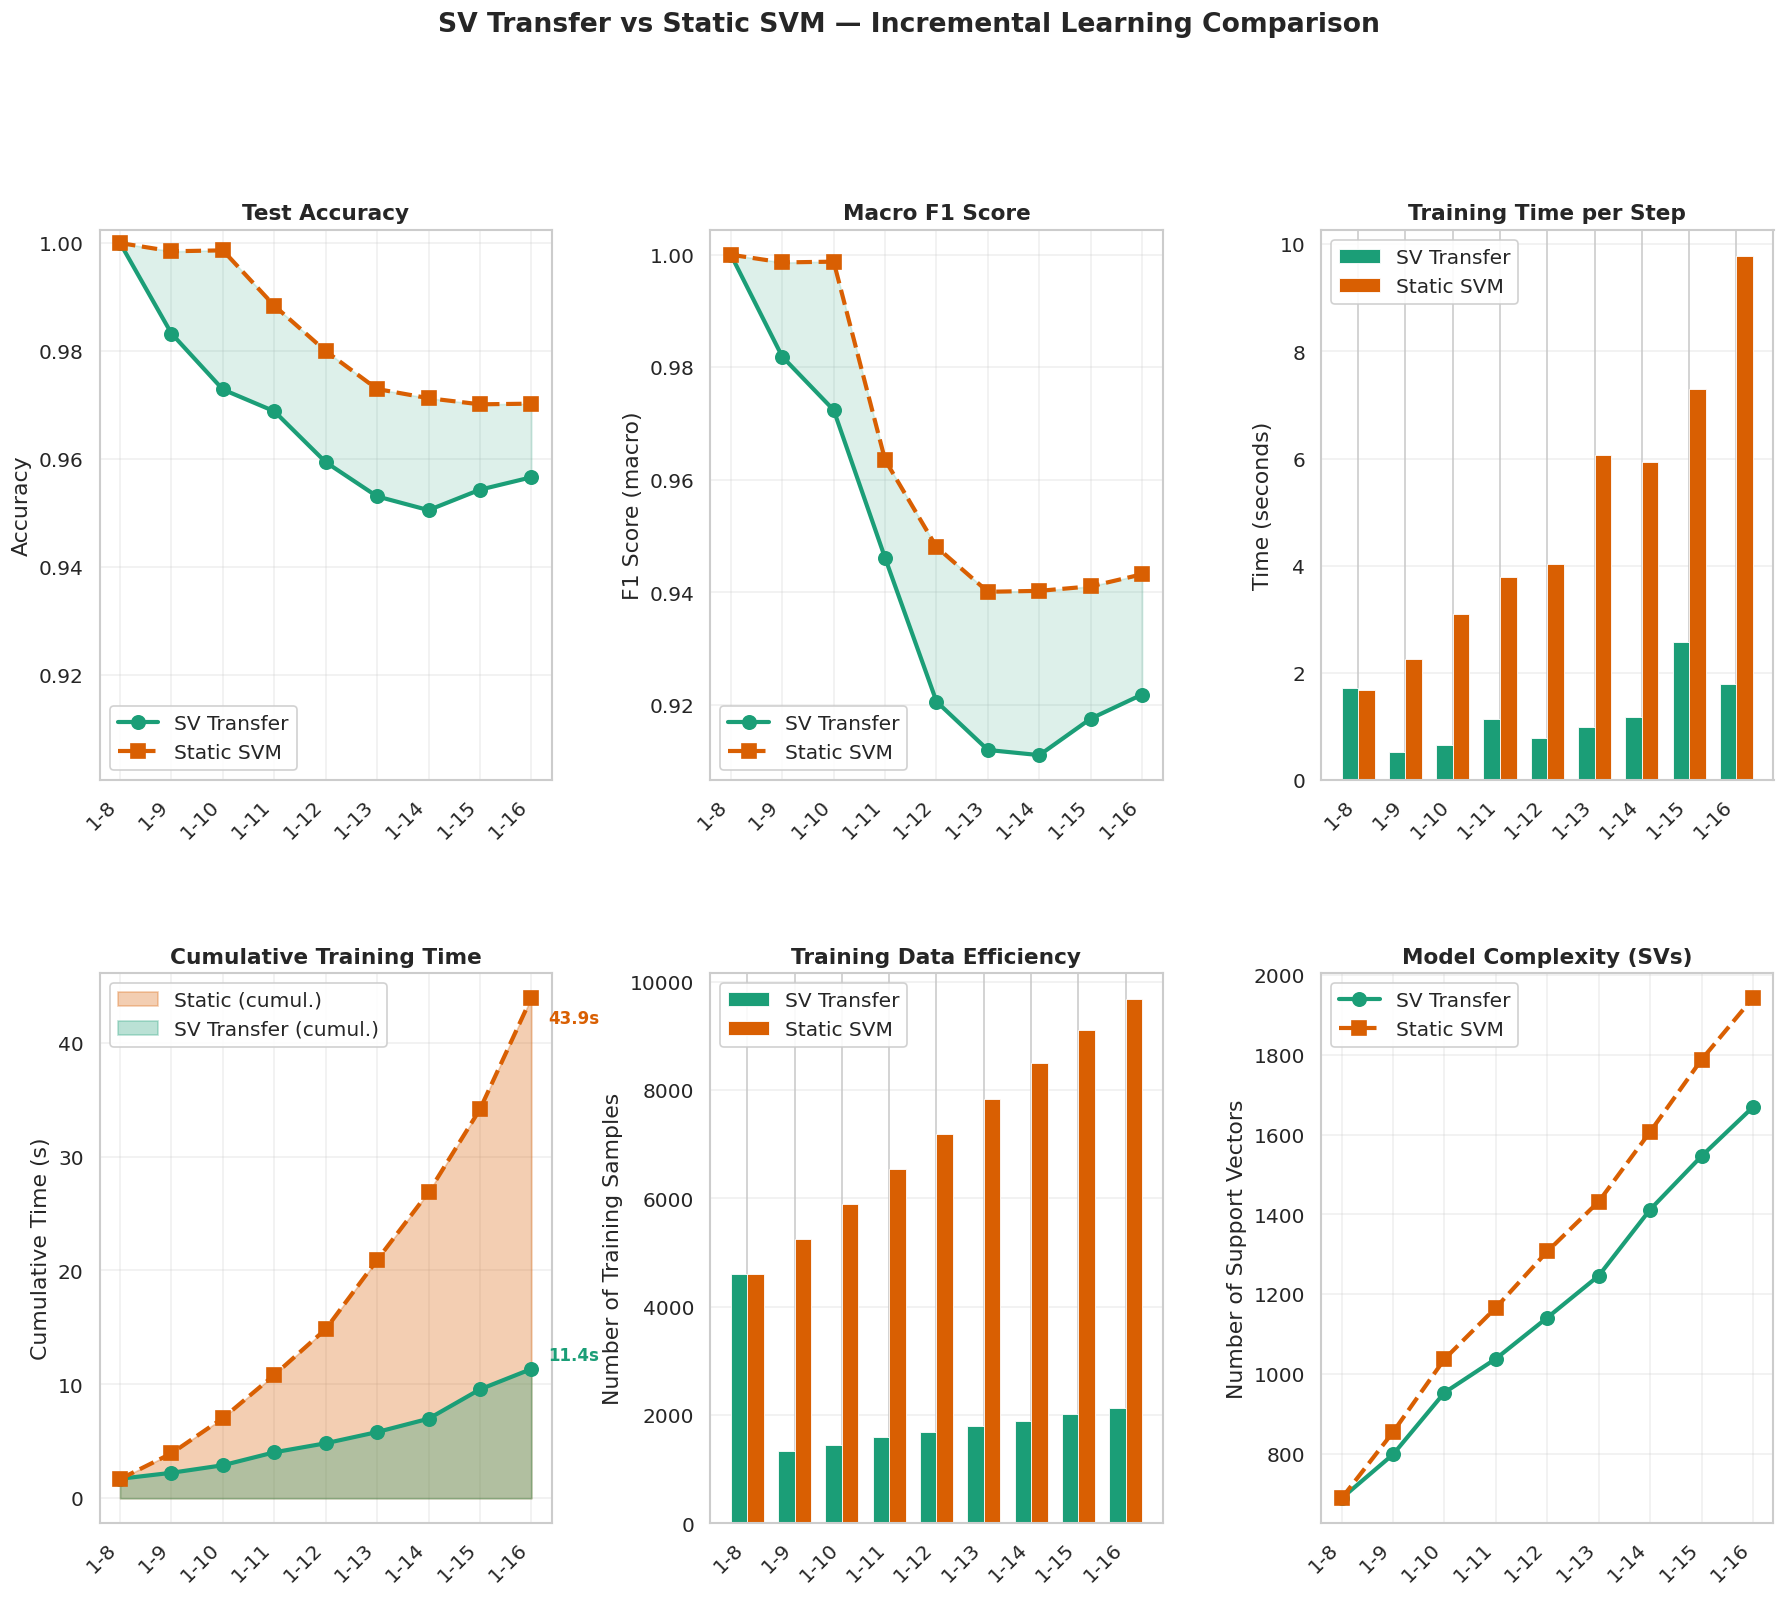

In [18]:
#schemes
C_SV     = '#1B9E77'
C_STATIC = '#D95F02'
C_SV_L   = '#A6DBA0'
C_STAT_L = '#FDB863'

fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(2, 3, hspace=0.35, wspace=0.35)

x = np.arange(len(steps))
w = 0.35

#accuracy scheme
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(x, df_sv['accuracy'], 'o-', color=C_SV, lw=2.5, ms=8,
         label='SV Transfer', zorder=5)
ax1.plot(x, df_st['accuracy'], 's--', color=C_STATIC, lw=2.5, ms=8,
         label='Static SVM', zorder=5)
ax1.fill_between(x, df_sv['accuracy'], df_st['accuracy'],
                 alpha=0.15, color=C_SV)
ax1.set_xticks(x)
ax1.set_xticklabels(steps, rotation=45, ha='right')
ax1.set_ylabel('Accuracy')
ax1.set_title('Test Accuracy', fontweight='bold', fontsize=13)
ax1.legend(loc='lower left', framealpha=0.9)
ax1.set_ylim(bottom=max(0, min(df_sv['accuracy'].min(), df_st['accuracy'].min()) - 0.05))
ax1.grid(True, alpha=0.3)


ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(x, df_sv['f1_macro'], 'o-', color=C_SV, lw=2.5, ms=8,
         label='SV Transfer')
ax2.plot(x, df_st['f1_macro'], 's--', color=C_STATIC, lw=2.5, ms=8,
         label='Static SVM')
ax2.fill_between(x, df_sv['f1_macro'], df_st['f1_macro'],
                 alpha=0.15, color=C_SV)
ax2.set_xticks(x)
ax2.set_xticklabels(steps, rotation=45, ha='right')
ax2.set_ylabel('F1 Score (macro)')
ax2.set_title('Macro F1 Score', fontweight='bold', fontsize=13)
ax2.legend(loc='lower left', framealpha=0.9)
ax2.grid(True, alpha=0.3)

# time
ax3 = fig.add_subplot(gs[0, 2])
bars1 = ax3.bar(x - w/2, df_sv['train_time'], w, color=C_SV,
                label='SV Transfer', edgecolor='white', linewidth=0.5)
bars2 = ax3.bar(x + w/2, df_st['train_time'], w, color=C_STATIC,
                label='Static SVM', edgecolor='white', linewidth=0.5)
ax3.set_xticks(x)
ax3.set_xticklabels(steps, rotation=45, ha='right')
ax3.set_ylabel('Time (seconds)')
ax3.set_title('Training Time per Step', fontweight='bold', fontsize=13)
ax3.legend(framealpha=0.9)
ax3.grid(True, alpha=0.3, axis='y')

# sum of time
ax4 = fig.add_subplot(gs[1, 0])
cum_sv = np.cumsum(df_sv['train_time'])
cum_st = np.cumsum(df_st['train_time'])
ax4.fill_between(x, cum_st, alpha=0.3, color=C_STATIC, label='Static (cumul.)')
ax4.fill_between(x, cum_sv, alpha=0.3, color=C_SV, label='SV Transfer (cumul.)')
ax4.plot(x, cum_sv, 'o-', color=C_SV, lw=2.5, ms=8)
ax4.plot(x, cum_st, 's--', color=C_STATIC, lw=2.5, ms=8)
ax4.annotate(f'{cum_sv.iloc[-1]:.1f}s', xy=(x[-1], cum_sv.iloc[-1]),
             fontsize=10, fontweight='bold', color=C_SV,
             textcoords='offset points', xytext=(10, 5))
ax4.annotate(f'{cum_st.iloc[-1]:.1f}s', xy=(x[-1], cum_st.iloc[-1]),
             fontsize=10, fontweight='bold', color=C_STATIC,
             textcoords='offset points', xytext=(10, -15))
ax4.set_xticks(x)
ax4.set_xticklabels(steps, rotation=45, ha='right')
ax4.set_ylabel('Cumulative Time (s)')
ax4.set_title('Cumulative Training Time', fontweight='bold', fontsize=13)
ax4.legend(framealpha=0.9)
ax4.grid(True, alpha=0.3)


ax5 = fig.add_subplot(gs[1, 1])
ax5.bar(x - w/2, df_sv['n_train_samples'], w, color=C_SV,
        label='SV Transfer', edgecolor='white', linewidth=0.5)
ax5.bar(x + w/2, df_st['n_train_samples'], w, color=C_STATIC,
        label='Static SVM', edgecolor='white', linewidth=0.5)
ax5.set_xticks(x)
ax5.set_xticklabels(steps, rotation=45, ha='right')
ax5.set_ylabel('Number of Training Samples')
ax5.set_title('Training Data Efficiency', fontweight='bold', fontsize=13)
ax5.legend(framealpha=0.9)
ax5.grid(True, alpha=0.3, axis='y')

# number of SVs
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(x, df_sv['n_sv'], 'o-', color=C_SV, lw=2.5, ms=8,
         label='SV Transfer')
ax6.plot(x, df_st['n_sv'], 's--', color=C_STATIC, lw=2.5, ms=8,
         label='Static SVM')
ax6.set_xticks(x)
ax6.set_xticklabels(steps, rotation=45, ha='right')
ax6.set_ylabel('Number of Support Vectors')
ax6.set_title('Model Complexity (SVs)', fontweight='bold', fontsize=13)
ax6.legend(framealpha=0.9)
ax6.grid(True, alpha=0.3)

fig.suptitle('SV Transfer vs Static SVM — Incremental Learning Comparison',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('comparison_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


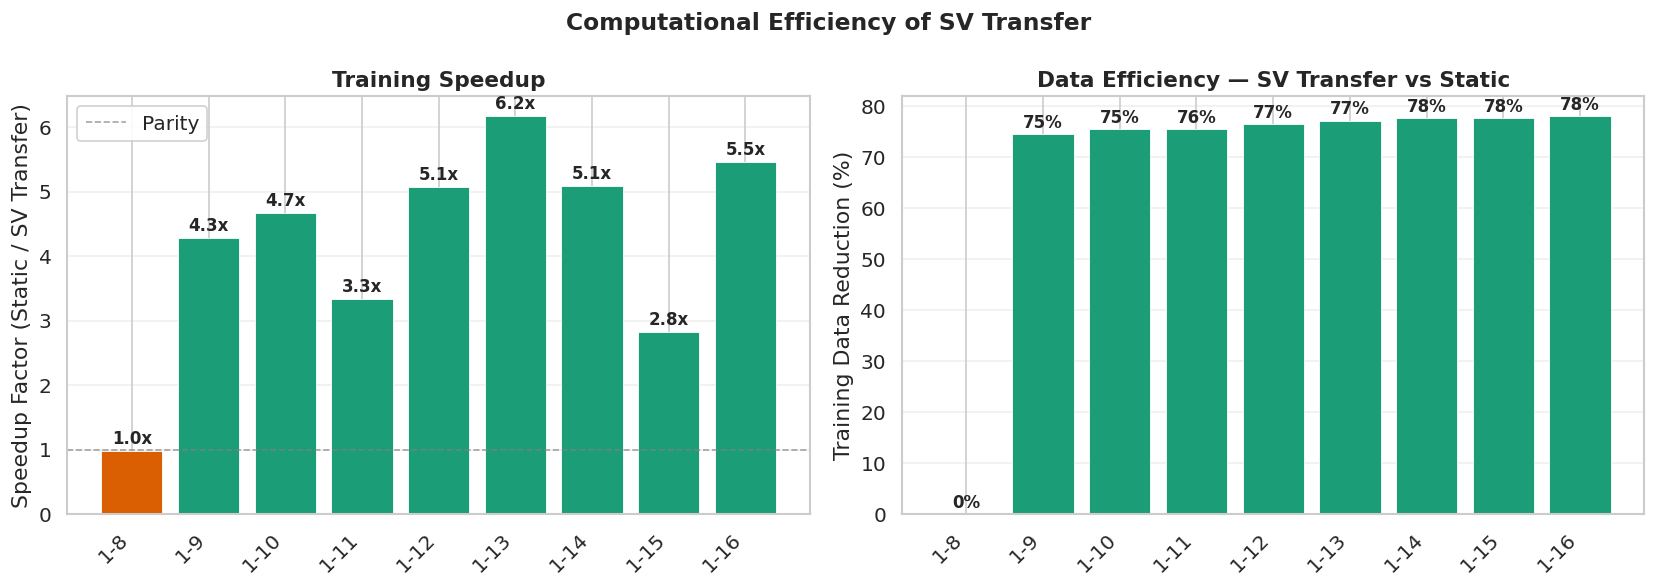

✓ Efficiency plot saved


In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

speedup = df_st['train_time'].values / df_sv['train_time'].values
colors_sp = [C_SV if s >= 1 else C_STATIC for s in speedup]
bars = ax1.bar(x, speedup, color=colors_sp, edgecolor='white', linewidth=0.5)
ax1.axhline(y=1, color='gray', linestyle='--', lw=1, alpha=0.7, label='Parity')
for i, s in enumerate(speedup):
    ax1.text(i, s + 0.05, f'{s:.1f}x', ha='center', va='bottom',
             fontsize=10, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(steps, rotation=45, ha='right')
ax1.set_ylabel('Speedup Factor (Static / SV Transfer)')
ax1.set_title('Training Speedup', fontweight='bold', fontsize=13)
ax1.legend(framealpha=0.9)
ax1.grid(True, alpha=0.3, axis='y')

reduction = (1 - df_sv['n_train_samples'].values / df_st['n_train_samples'].values) * 100
bars2 = ax1_b = ax2.bar(x, reduction, color=C_SV, edgecolor='white', linewidth=0.5)
for i, r in enumerate(reduction):
    ax2.text(i, r + 0.5, f'{r:.0f}%', ha='center', va='bottom',
             fontsize=10, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(steps, rotation=45, ha='right')
ax2.set_ylabel('Training Data Reduction (%)')
ax2.set_title('Data Efficiency — SV Transfer vs Static', fontweight='bold', fontsize=13)
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Computational Efficiency of SV Transfer',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('efficiency_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Efficiency plot saved")

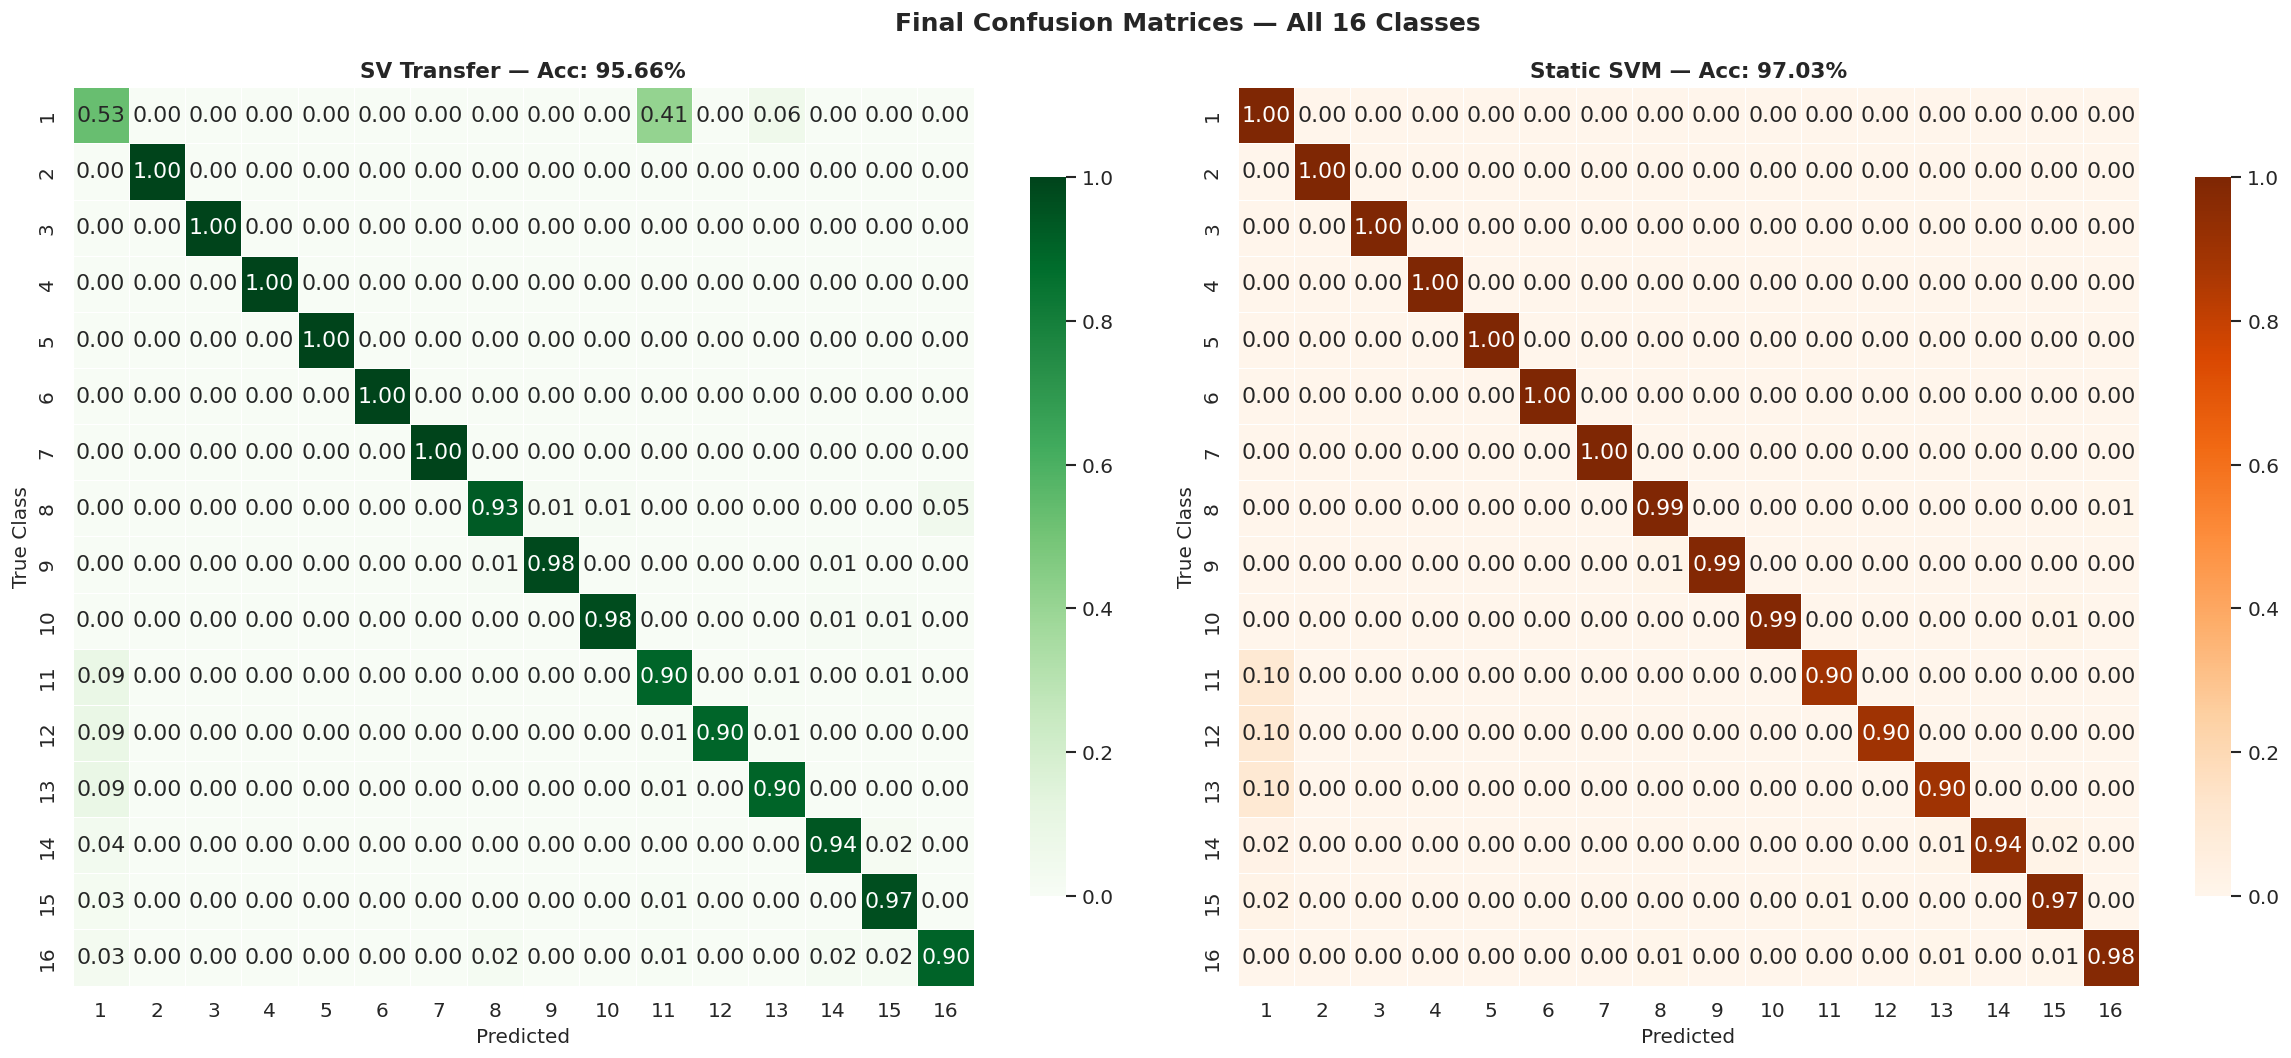

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

all_labels = np.array(sorted(np.unique(y_test_all)))

for ax, expert, X_data, y_data, title, cmap in [
    (ax1, sv_current_expert, sv_current_X, sv_current_y,
     f'SV Transfer — Acc: {df_sv["accuracy"].iloc[-1]:.2%}', 'Greens'),
    (ax2, st_expert, st_accum_X, st_accum_y,
     f'Static SVM — Acc: {df_st["accuracy"].iloc[-1]:.2%}', 'Oranges'),
]:
    y_pred = expert.predict(X_test_sc)
    cm = confusion_matrix(y_test_all, y_pred, labels=all_labels)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_norm = np.nan_to_num(cm_norm)

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap=cmap,
                xticklabels=all_labels.astype(int),
                yticklabels=all_labels.astype(int),
                ax=ax, vmin=0, vmax=1, linewidths=0.5,
                cbar_kws={'shrink': 0.8})
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('True Class', fontsize=12)
    ax.set_title(title, fontweight='bold', fontsize=13)

plt.suptitle('Final Confusion Matrices — All 16 Classes',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Final accuracy comparison
print(f"\n📊 Final Accuracy (16 classes):")
print(f"   SV Transfer : {df_sv['accuracy'].iloc[-1]:.4f}")
print(f"   Static SVM  : {df_st['accuracy'].iloc[-1]:.4f}")
diff = df_sv['accuracy'].iloc[-1] - df_st['accuracy'].iloc[-1]
print(f"   Difference  : {diff:+.4f} ({'SV Transfer' if diff >= 0 else 'Static'} wins)")

# time
total_sv = df_sv['train_time'].sum()
total_st = df_st['train_time'].sum()
print(f"\n Total Training Time:")
print(f"   SV Transfer : {total_sv:.2f}s")
print(f"   Static SVM  : {total_st:.2f}s")
print(f"   Speedup     : {total_st/total_sv:.1f}x")

# samples
print(f"\n Training Samples (last step):")
print(f"   SV Transfer : {df_sv['n_train_samples'].iloc[-1]}")
print(f"   Static SVM  : {df_st['n_train_samples'].iloc[-1]}")
reduction = (1 - df_sv['n_train_samples'].iloc[-1] / df_st['n_train_samples'].iloc[-1]) * 100
print(f"   Reduction   : {reduction:.1f}%")

# sVs
print(f"\n Support Vectors (last step):")
print(f"   SV Transfer : {df_sv['n_sv'].iloc[-1]}")
print(f"   Static SVM  : {df_st['n_sv'].iloc[-1]}")



📊 Final Accuracy (16 classes):
   SV Transfer : 0.9566
   Static SVM  : 0.9703
   Difference  : -0.0136 (Static wins)

 Total Training Time:
   SV Transfer : 11.35s
   Static SVM  : 43.94s
   Speedup     : 3.9x

 Training Samples (last step):
   SV Transfer : 2122
   Static SVM  : 9680
   Reduction   : 78.1%

 Support Vectors (last step):
   SV Transfer : 1669
   Static SVM  : 1943


In [ ]:
#save results
results = {
    'sv_transfer': df_sv.to_dict('records'),
    'static_svm': df_st.to_dict('records'),
    'steps': steps,
}

import pickle
with open('comparison_sv_vs_static.pkl', 'wb') as f:
    pickle.dump(results, f)

summary.to_csv('comparison_summary.csv')

files.download('comparison_summary.csv')
